In [4]:
import math

import torch
from matplotlib import pyplot as plt

from hyperbolic.poincare import exp_map, exp_map_2, geodesic

In [44]:
# create points on disk where z2 should be otimised
data = torch.tensor([[-0.5 + 0.5j], [0.5 + 0.5j], [-0.3 - 0.4j]], dtype=torch.complex64)

grad_0 = torch.tensor([0.2 - 0.2j])
grad_1 = torch.tensor([0.0 - 0.4j])
grad_2 = torch.tensor([0.2 - 0.4j])

z_0_mapped = exp_map_2(data[0], grad_0)
z_1_mapped = exp_map_2(data[1], grad_1)
z_2_mapped = exp_map_2(data[2], grad_2)

annotates = [
    [r"$z_0$", data[0]],
    [r"$z_1$", data[1]],
    [r"$z_2$", data[2]],
    [r"$\text{exp}_{z_0}(v_0)$", z_0_mapped],
    [r"$\text{exp}_{z_1}(v_1)$", z_1_mapped],
    [r"$\text{exp}_{z_2}(v_2)$", z_2_mapped],
]

# values the geodesic curve gets computed for
ts = torch.linspace(-10, 10, 1000).reshape(1000, 1)

# compute geodesics
geod_exp_map_0 = torch.vmap(geodesic, in_dims=(None, None, 0, None))(
    data[0], z_0_mapped, ts, "disk"
)
geod_exp_map_1 = torch.vmap(geodesic, in_dims=(None, None, 0, None))(
    data[1], z_1_mapped, ts, "disk"
)
geod_exp_map_2 = torch.vmap(geodesic, in_dims=(None, None, 0, None))(
    data[2], z_2_mapped, ts, "disk"
)

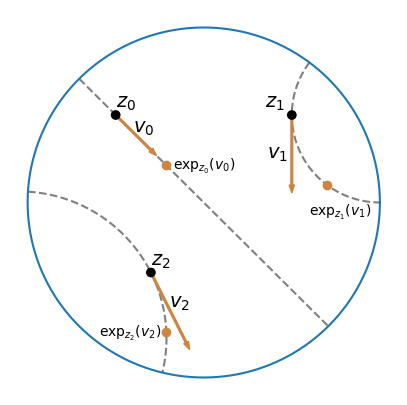

In [58]:
x_sphere = torch.cos(torch.linspace(0, 2 * math.pi, 1000))
y_sphere = torch.sin(torch.linspace(0, 2 * math.pi, 1000))
sphere = torch.complex(x_sphere, y_sphere)

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.plot(
    geod_exp_map_0.real, geod_exp_map_0.imag, color="grey", linestyle="dashed", zorder=0
)
ax.plot(
    geod_exp_map_1.real, geod_exp_map_1.imag, color="grey", linestyle="dashed", zorder=0
)
ax.plot(
    geod_exp_map_2.real, geod_exp_map_2.imag, color="grey", linestyle="dashed", zorder=0
)

ax.arrow(
    data[0].real.item(),
    data[0].imag.item(),
    grad_0.real.item(),
    grad_0.imag.item(),
    color="peru",
    width=0.01,
    alpha=1,
)
ax.arrow(
    data[1].real.item(),
    data[1].imag.item(),
    grad_1.real.item(),
    grad_1.imag.item(),
    color="peru",
    width=0.01,
    alpha=1,
)
ax.arrow(
    data[2].real.item(),
    data[2].imag.item(),
    grad_2.real.item(),
    grad_2.imag.item(),
    color="peru",
    width=0.01,
    alpha=1,
)

ax.scatter(data.detach().real, data.detach().imag, color=["black", "black", "black"])
ax.scatter(z_0_mapped.detach().real, z_0_mapped.detach().imag, color="peru")
ax.scatter(z_1_mapped.detach().real, z_1_mapped.detach().imag, color="peru")
ax.scatter(z_2_mapped.detach().real, z_2_mapped.detach().imag, color="peru")

# annotate points
ax.annotate(annotates[0][0], (annotates[0][1].real, annotates[0][1].imag + 0.04), fontsize=14, c="black")
ax.annotate(annotates[1][0], (annotates[1][1].real-0.15, annotates[1][1].imag + 0.04), fontsize=14, c="black")
ax.annotate(annotates[2][0], (annotates[2][1].real, annotates[2][1].imag + 0.04), fontsize=14, c="black")

# annotate exp_maps
ax.annotate(annotates[3][0], (annotates[3][1].real+0.04, annotates[3][1].imag-0.03), fontsize=10, c="black")
ax.annotate(annotates[4][0], (annotates[4][1].real-0.10, annotates[4][1].imag-0.18), fontsize=10, c="black")
ax.annotate(annotates[5][0], (annotates[5][1].real-0.38, annotates[5][1].imag-0.03), fontsize=10, c="black")

# annotate gradients
ax.annotate(r"$v_0$", (-0.4, .4), fontsize=14, c="black")
ax.annotate(r"$v_1$", (0.36, 0.25), fontsize=14, c="black")
ax.annotate(r"$v_2$", (-0.2, -0.6), fontsize=14, c="black")

ax.plot(sphere.real, sphere.imag)
ax.axis("off")
plt.savefig("images/exp_map.png", dpi=500)
plt.show()